In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

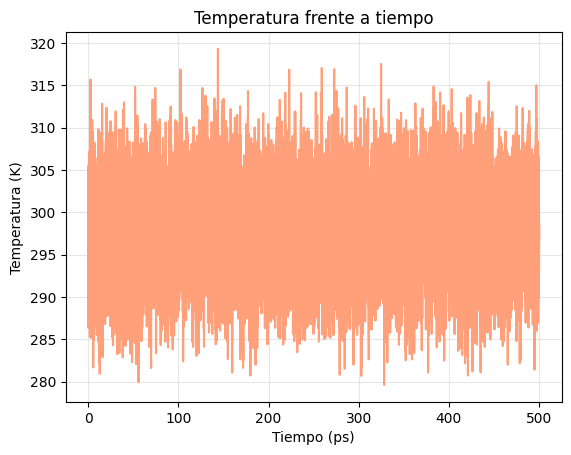

In [4]:
data = np.loadtxt("temp.xvg", comments=['#', '@'])

plt.plot(data[:, 0], data[:, 1:].sum(axis=1), 
         color=mcolors.CSS4_COLORS['lightsalmon'],  linestyle='-')
plt.xlabel("Tiempo (ps)") 
plt.ylabel("Temperatura (K)") 
plt.title("Temperatura frente a tiempo") 
plt.grid(alpha=0.3)
plt.show()

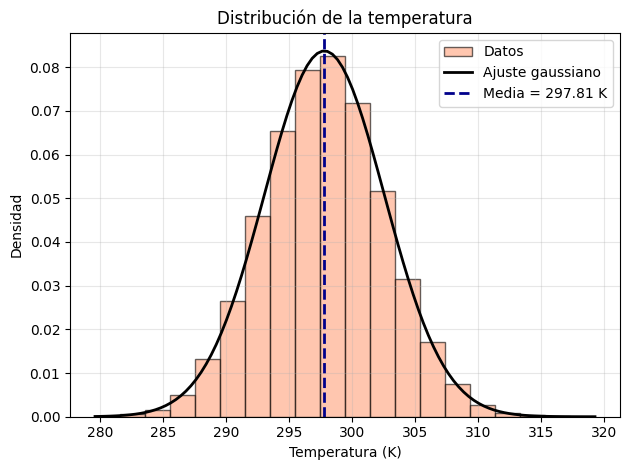

In [7]:
temp = data[:, 1]

# Parámetros
media = np.mean(temp)
std = np.std(temp)

plt.figure()

# Histograma normalizado
count, bins, _ = plt.hist(temp, bins=20, density=True,
                          edgecolor='black', alpha=0.6,
                          label='Datos', color=mcolors.CSS4_COLORS['lightsalmon'])

# Curva gaussiana
x = np.linspace(min(temp), max(temp), 100)
gauss = (1/(std*np.sqrt(2*np.pi))) * np.exp(-(x-media)**2/(2*std**2))

plt.plot(x, gauss, linewidth=2, label='Ajuste gaussiano', color=mcolors.CSS4_COLORS['black'] )

# Media
media = np.mean(data[:, 1])
plt.axvline(media, linestyle='--', linewidth=2, label=f'Media = {media:.2f} K',
            color=mcolors.CSS4_COLORS['darkblue'])

# Etiquetas
plt.xlabel('Temperatura (K)')
plt.ylabel('Densidad')
plt.title('Distribución de la temperatura')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

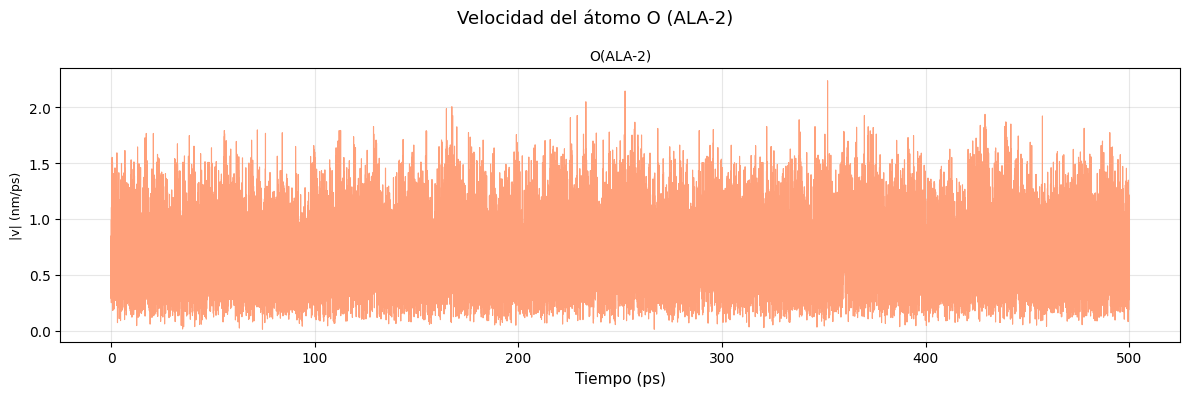

In [16]:
data = np.loadtxt('veloc-atomo.xvg')
tiempo = data[:, 0]

atom = data[:, 1:4]

fig, ax = plt.subplots(1, 1, figsize=(12, 4), sharex=True)

magnitud = np.sqrt(np.sum(atom**2, axis=1))
ax.plot(tiempo, magnitud, linewidth=0.8, color=mcolors.CSS4_COLORS['lightsalmon'])
ax.set_ylabel('|v| (nm/ps)', fontsize=9)
ax.set_title('O(ALA-2)', fontsize=10)
plt.grid(alpha=0.3)

ax.set_xlabel('Tiempo (ps)', fontsize=11)
plt.suptitle('Velocidad del átomo O (ALA-2)', fontsize=13)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


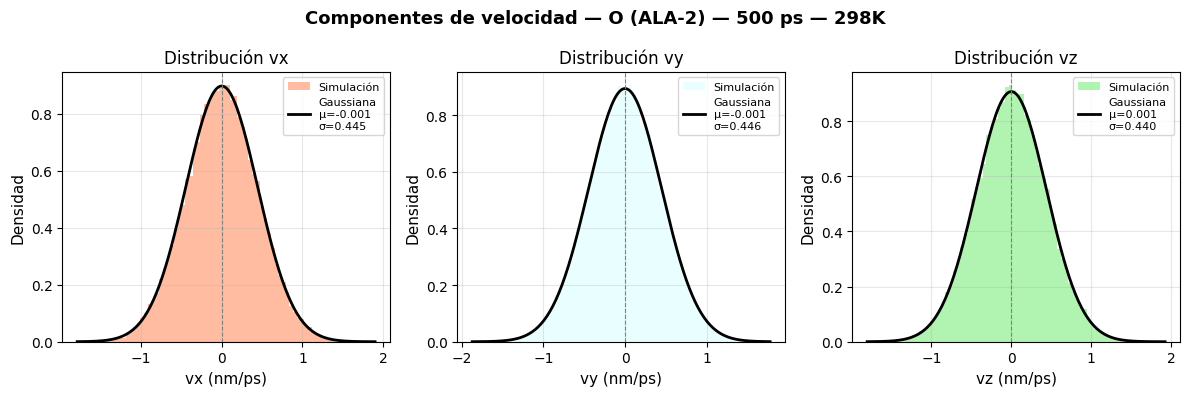

In [19]:
from scipy.stats import norm

data = np.loadtxt('veloc-atomo.xvg')
tiempo = data[:, 0]
vx = data[:, 1]
vy = data[:, 2]
vz = data[:, 3]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

colores = ['lightsalmon', 'lightcyan', 'lightgreen']

for ax, v, label, color in zip(axes, [vx, vy, vz], ['vx', 'vy', 'vz'], colores):
    ax.hist(v, bins=80, density=True, alpha=0.7, 
            color=color, label='Simulación')
    
    # Ajuste gaussiano
    mu, sigma = norm.fit(v)
    x = np.linspace(min(v), max(v), 200)
    ax.plot(x, norm.pdf(x, mu, sigma), 'k-', lw=2, 
            label=f'Gaussiana\nμ={mu:.3f}\nσ={sigma:.3f}')
    
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel(f'{label} (nm/ps)', fontsize=11)
    ax.set_ylabel('Densidad', fontsize=11)
    ax.set_title(f'Distribución {label}', fontsize=12)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('Componentes de velocidad — O (ALA-2) — 500 ps — 298K', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('veloc_componentes_500ps.png', dpi=150, bbox_inches='tight')
plt.show()

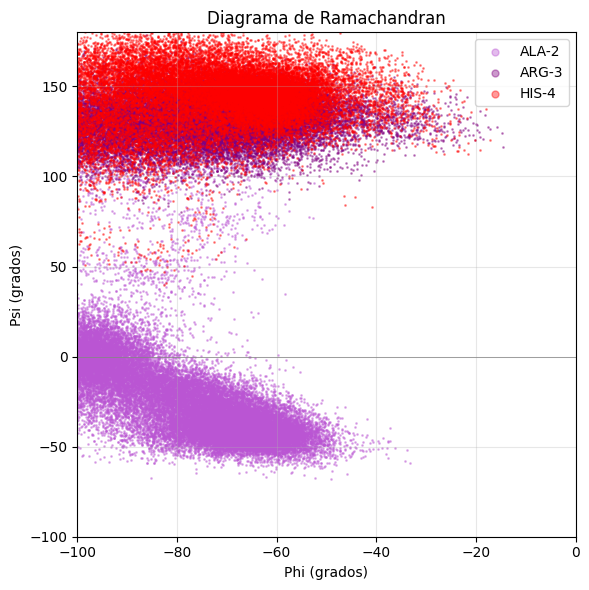

In [21]:
phi = []
psi = []
residuos = []


with open('rama.xvg', 'r') as f:
    for line in f:
        # Saltar líneas de comentario
        if line.startswith('#') or line.startswith('@'):
            continue
        cols = line.split()
        if len(cols) >= 3:
            phi.append(float(cols[0]))
            psi.append(float(cols[1]))
            residuos.append(cols[2])

phi = np.array(phi)
psi = np.array(psi)
residuos = np.array(residuos)

# Plot general
plt.figure(figsize=(6,6))
# Por residuo con colores personalizados
colores = {
    'ALA-2': 'mediumorchid',
    'ARG-3': 'purple',
    'HIS-4': 'r'
}

for res in np.unique(residuos):
    mask = residuos == res
    plt.scatter(phi[mask], psi[mask], s=1, alpha=0.4, 
                color=colores.get(res, 'gray'), label=res)
plt.xlabel('Phi (grados)')
plt.ylabel('Psi (grados)')
plt.title('Diagrama de Ramachandran')
plt.xlim(-100, 0)
plt.ylim(-100, 180)
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.legend(markerscale=5)
plt.tight_layout()
#plt.savefig('ramachandran.png', dpi=150)
plt.show()

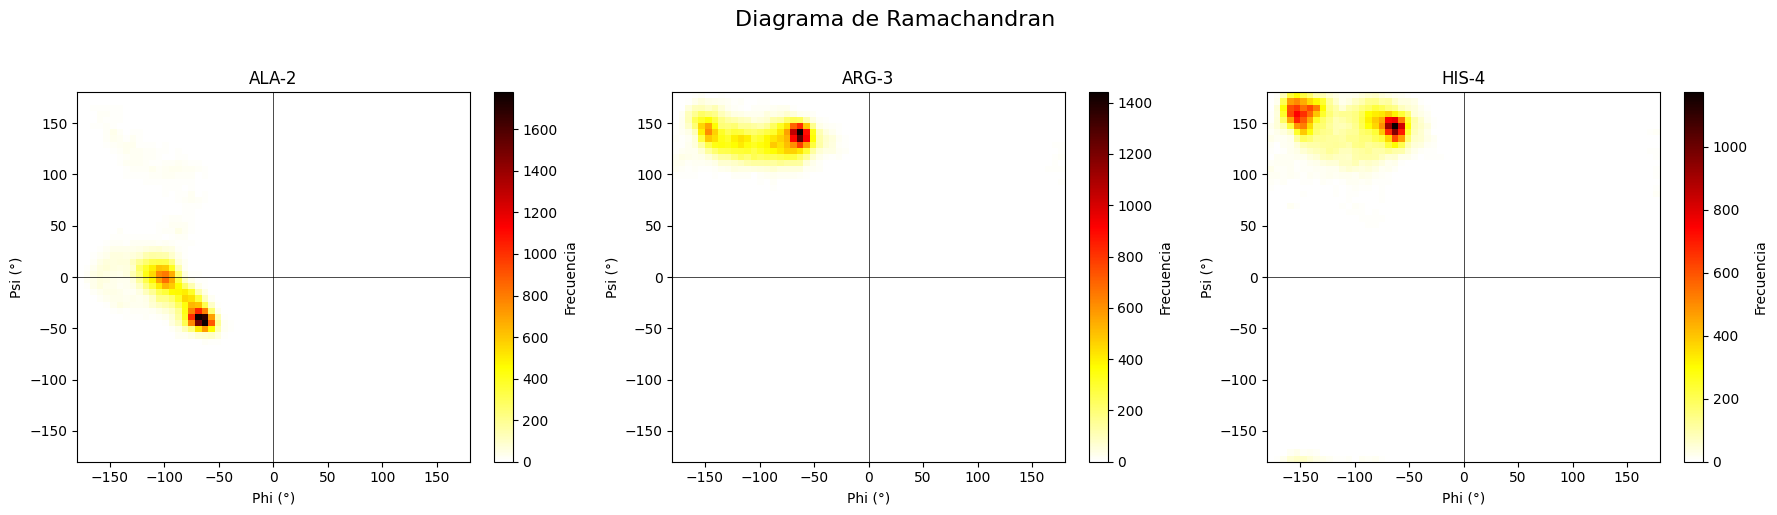

In [23]:
residuos_unicos = np.unique(residuos)
fig, axes = plt.subplots(1, len(residuos_unicos), figsize=(6*len(residuos_unicos), 5))

# Si solo hay un residuo, axes no es lista
if len(residuos_unicos) == 1:
    axes = [axes]

for ax, res in zip(axes, residuos_unicos):
    mask = residuos == res
    h = ax.hist2d(phi[mask], psi[mask], 
                  bins=60,                    # resolución del mapa
                  range=[[-180,180],[-180,180]],
                  cmap='hot_r')               # paleta de color
    plt.colorbar(h[3], ax=ax, label='Frecuencia')
    ax.set_xlabel('Phi (°)')
    ax.set_ylabel('Psi (°)')
    ax.set_title(f'{res}')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)

plt.suptitle('Diagrama de Ramachandran', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()